# COMPARATIVA - Análisis Descriptivo y Visual de las 8 Dimensiones

Este notebook presenta un análisis comparativo completo de las 8 dimensiones de calidad de datos:

1. Completitud
2. Exactitud
3. Consistencia
4. Integridad
5. Razonabilidad
6. Oportunidad
7. Unicidad
8. Validez

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")
print(f"📅 Análisis COMPARATIVO ejecutado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías cargadas correctamente
📅 Análisis COMPARATIVO ejecutado: 2026-05-21 11:55:08


In [2]:
# Cargar datos de Ingresos Históricos Municipalidades SIAF
df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')

# Filtrar municipalidades y crear copia de trabajo
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

print(f"✅ Dataset cargado correctamente")
print(f"📊 Total registros dataset     : {len(df):,}")
print(f"🏘️  Registros municipalidades  : {len(df_munic):,}")
print(f"📋 Total columnas              : {len(df.columns)}")
print(f"📅 Rango de años              : {df_munic['ANO_DOC'].min()} - {df_munic['ANO_DOC'].max()}")
print(f"🗂️  Columnas: {list(df.columns)}")

✅ Dataset cargado correctamente
📊 Total registros dataset     : 10,777,068
🏘️  Registros municipalidades  : 8,880,692
📋 Total columnas              : 37
📅 Rango de años              : 2012 - 2026
🗂️  Columnas: ['ANO_DOC', 'MES_DOC', 'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE', 'SECTOR', 'SECTOR_NOMBRE', 'PLIEGO', 'PLIEGO_NOMBRE', 'SEC_EJEC', 'EJECUTORA', 'EJECUTORA_NOMBRE', 'DEPARTAMENTO_EJECUTORA', 'DEPARTAMENTO_EJECUTORA_NOMBRE', 'PROVINCIA_EJECUTORA', 'PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA', 'DISTRITO_EJECUTORA_NOMBRE', 'FUENTE_FINANCIAMIENTO', 'FUENTE_FINANCIAMIENTO_NOMBRE', 'RUBRO', 'RUBRO_NOMBRE', 'TIPO_RECURSO', 'TIPO_RECURSO_NOMBRE', 'GENERICA', 'GENERICA_NOMBRE', 'SUBGENERICA', 'SUBGENERICA_NOMBRE', 'SUBGENERICA_DET', 'SUBGENERICA_DET_NOMBRE', 'ESPECIFICA', 'ESPECIFICA_NOMBRE', 'ESPECIFICA_DET', 'ESPECIFICA_DET_NOMBRE', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO', 'ARCHIVO_ORIGEN']


## Análisis por Dimensión

In [3]:
# FUNCIÓN HELPER - Cálculo de métricas por dimensión de calidad
# Ingresos Municipalidades SIAF 2012-2026

def calcular_metricas_dimension(
    nombre: str,
    registros_problema,
    total: int
) -> dict:
    """
    Calcula métricas de calidad para una dimensión específica.

    Args:
        nombre: Nombre de la dimensión (ej: 'Completitud', 'Exactitud')
        registros_problema: DataFrame o lista con registros problemáticos
        total: Total de registros de municipalidades analizados

    Returns:
        Diccionario con métricas clave de la dimensión
    """
    cantidad       = len(registros_problema)
    porcentaje     = (cantidad / total) * 100 if total > 0 else 0
    registros_ok   = total - cantidad
    porcentaje_ok  = 100 - porcentaje

    severidad = (
        '🔴 CRÍTICO'   if porcentaje > 10
        else '🟡 MODERADO' if porcentaje > 2
        else '🟢 ACEPTABLE'
    )

    return {
        'dimension':             nombre,
        'total_registros':       total,
        'problemas':             cantidad,
        'porcentaje_problemas':  round(porcentaje, 2),
        'registros_ok':          registros_ok,
        'porcentaje_ok':         round(porcentaje_ok, 2),
        'severidad':             severidad
    }


# Verificar función con ejemplo rápido
print("✅ Función calcular_metricas_dimension definida correctamente")
print("\nEjemplo de uso:")
ejemplo = calcular_metricas_dimension(
    'Ejemplo',
    df_munic[df_munic['MONTO_PIA'] < 0],
    len(df_munic)
)
for k, v in ejemplo.items():
    print(f"   {k:<25}: {v}")

✅ Función calcular_metricas_dimension definida correctamente

Ejemplo de uso:
   dimension                : Ejemplo
   total_registros          : 8880692
   problemas                : 0
   porcentaje_problemas     : 0.0
   registros_ok             : 8880692
   porcentaje_ok            : 100.0
   severidad                : 🟢 ACEPTABLE


In [4]:
# Definir parámetros y reglas de negocio - Ingresos Municipalidades SIAF

# Columnas críticas para el análisis presupuestal
COLUMNAS_CRITICAS = [
    'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
    'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
    'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]

# Valores permitidos por el MEF
NIVELES_VALIDOS      = ['E', 'R', 'M']
FUENTES_VALIDAS      = [1, 2, 3, 4, 5]
RANGO_ANIOS          = (2012, 2026)
RANGO_MESES          = (1, 12)
RANGO_DEPARTAMENTOS  = (1, 25)

# Mapeo código → nombre de nivel de gobierno
REGLAS_NIVEL_GOBIERNO = {
    'E': 'GOBIERNO NACIONAL',
    'R': 'GOBIERNOS REGIONALES',
    'M': 'GOBIERNOS LOCALES'
}

# Base de trabajo: solo municipalidades
total_registros = len(df_munic)
metricas        = []

print("✅ Parámetros y reglas de negocio definidos")
print(f"\n📌 Configuración del análisis:")
print(f"   Total registros municipalidades : {total_registros:,}")
print(f"   Rango de años esperado          : {RANGO_ANIOS[0]} - {RANGO_ANIOS[1]}")
print(f"   Fuentes de financiamiento válidas: {FUENTES_VALIDAS}")
print(f"   Rango de departamentos válido   : {RANGO_DEPARTAMENTOS[0]:02d} - {RANGO_DEPARTAMENTOS[1]:02d}")
print(f"   Columnas críticas               : {len(COLUMNAS_CRITICAS)}")

✅ Parámetros y reglas de negocio definidos

📌 Configuración del análisis:
   Total registros municipalidades : 8,880,692
   Rango de años esperado          : 2012 - 2026
   Fuentes de financiamiento válidas: [1, 2, 3, 4, 5]
   Rango de departamentos válido   : 01 - 25
   Columnas críticas               : 7


### 1. Completitud

In [5]:
# COMPLETITUD - Análisis de valores faltantes en municipalidades SIAF

# Total de celdas faltantes en columnas críticas
faltantes_criticos = df_munic[COLUMNAS_CRITICAS].isnull().sum().sum()
faltantes_total    = df_munic.isnull().sum().sum()

metricas.append(calcular_metricas_dimension(
    'Completitud',
    pd.Series(range(faltantes_criticos)),
    total_registros
))

# Detalle por columna
completitud_por_columna = pd.DataFrame({
    'Columna':    df_munic.columns,
    'Faltantes':  [df_munic[col].isnull().sum() for col in df_munic.columns],
    'Porcentaje': [
        round((df_munic[col].isnull().sum() / total_registros) * 100, 2)
        for col in df_munic.columns
    ]
}).sort_values('Faltantes', ascending=False)

completitud_por_columna['Es_Crítica'] = completitud_por_columna['Columna'].isin(
    COLUMNAS_CRITICAS
)
completitud_por_columna['Severidad'] = completitud_por_columna.apply(
    lambda r: '🔴 CRÍTICO'   if (r['Es_Crítica'] and r['Faltantes'] > 0)
              or r['Porcentaje'] > 10
    else      '🟡 MODERADO' if r['Porcentaje'] > 2
    else      '🟢 ACEPTABLE',
    axis=1
)

print("=" * 65)
print("   COMPLETITUD — Valores Faltantes por Columna")
print("   Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal celdas faltantes (todas las columnas) : {faltantes_total:,}")
print(f"Total celdas faltantes (columnas críticas)  : {faltantes_criticos:,}")
print()

cols_con_faltantes = completitud_por_columna[
    completitud_por_columna['Faltantes'] > 0
]

if len(cols_con_faltantes) == 0:
    print("✅ No se encontraron valores faltantes en ninguna columna")
else:
    print(cols_con_faltantes[
        ['Columna', 'Faltantes', 'Porcentaje', 'Es_Crítica', 'Severidad']
    ].to_string(index=False))

   COMPLETITUD — Valores Faltantes por Columna
   Municipalidades SIAF 2012-2026

Total celdas faltantes (todas las columnas) : 0
Total celdas faltantes (columnas críticas)  : 0

✅ No se encontraron valores faltantes en ninguna columna


### 2. Exactitud

In [6]:
# EXACTITUD - Validación de montos presupuestales municipalidades SIAF

pia_negativos        = df_munic[df_munic['MONTO_PIA'] < 0]
pim_negativos        = df_munic[df_munic['MONTO_PIM'] < 0]
recaudado_negativos  = df_munic[df_munic['MONTO_RECAUDADO'] < 0]
pim_menor_pia        = df_munic[
    (df_munic['MONTO_PIM'] < df_munic['MONTO_PIA']) &
    (df_munic['MONTO_PIA'] > 0)
]
recaudado_anomalo    = df_munic[
    (df_munic['MONTO_PIM'] > 0) &
    (df_munic['MONTO_RECAUDADO'] > df_munic['MONTO_PIM'] * 2)
]

problemas_exactitud = (
    len(pia_negativos)       +
    len(pim_negativos)       +
    len(recaudado_negativos) +
    len(pim_menor_pia)       +
    len(recaudado_anomalo)
)

metricas.append(calcular_metricas_dimension(
    'Exactitud',
    pd.Series(range(problemas_exactitud)),
    total_registros
))

print("=" * 65)
print("   EXACTITUD — Montos Presupuestales Municipalidades")
print("   SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print()

detalle_exactitud = {
    'MONTO_PIA negativos':          len(pia_negativos),
    'MONTO_PIM negativos':          len(pim_negativos),
    'MONTO_RECAUDADO negativos':    len(recaudado_negativos),
    'PIM menor que PIA':            len(pim_menor_pia),
    'Recaudado mayor a 2x PIM':     len(recaudado_anomalo)
}

for descripcion, cantidad in detalle_exactitud.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<35}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

print(f"\n   {'─' * 50}")
print(f"   📊 TOTAL problemas de exactitud    : "
      f"{problemas_exactitud:,} "
      f"({problemas_exactitud/total_registros*100:.2f}%)")

   EXACTITUD — Montos Presupuestales Municipalidades
   SIAF 2012-2026

Total registros municipalidades: 8,880,692

   ✅ MONTO_PIA negativos                : 0 (0.00%)
   ⚠️  MONTO_PIM negativos                : 13,503 (0.15%)
   ⚠️  MONTO_RECAUDADO negativos          : 62,726 (0.71%)
   ⚠️  PIM menor que PIA                  : 18,269 (0.21%)
   ⚠️  Recaudado mayor a 2x PIM           : 7,818 (0.09%)

   ──────────────────────────────────────────────────
   📊 TOTAL problemas de exactitud    : 102,316 (1.15%)


### 3. Consistencia

In [7]:
# CONSISTENCIA - Coherencia entre campos del SIAF municipalidades

df_temp = df_munic.copy()

# 1. Consistencia nivel gobierno: código vs nombre
df_temp['NIVEL_NOMBRE_ESPERADO'] = df_temp['NIVEL_GOBIERNO'].map(
    REGLAS_NIVEL_GOBIERNO
)
inconsist_nivel = df_temp[
    df_temp['NIVEL_GOBIERNO_NOMBRE'] != df_temp['NIVEL_NOMBRE_ESPERADO']
]

# 2. Consistencia fuente financiamiento: código siempre con mismo nombre
fuente_check          = df_temp.groupby('FUENTE_FINANCIAMIENTO')[
    'FUENTE_FINANCIAMIENTO_NOMBRE'
].nunique()
inconsist_fuente      = fuente_check[fuente_check > 1]

# 3. Consistencia rubro: código siempre con mismo nombre
rubro_check           = df_temp.groupby('RUBRO')['RUBRO_NOMBRE'].nunique()
inconsist_rubro       = rubro_check[rubro_check > 1]

# 4. Consistencia temporal: ANO_DOC vs año del archivo origen
df_temp['ANO_ORIGEN'] = df_temp['ARCHIVO_ORIGEN'].str.extract(
    r'(\d{4})'
).astype(float)
inconsist_anio        = df_temp[df_temp['ANO_DOC'] != df_temp['ANO_ORIGEN']]

problemas_consistencia = (
    len(inconsist_nivel)   +
    len(inconsist_fuente)  +
    len(inconsist_rubro)   +
    len(inconsist_anio)
)

metricas.append(calcular_metricas_dimension(
    'Consistencia',
    pd.Series(range(problemas_consistencia)),
    total_registros
))

print("=" * 65)
print("   CONSISTENCIA — Coherencia entre Campos SIAF")
print("   Municipalidades 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print()

detalle_consistencia = {
    'Nivel gobierno: código vs nombre':     len(inconsist_nivel),
    'Fuente financ.: código vs nombre':     len(inconsist_fuente),
    'Rubro: código vs nombre':              len(inconsist_rubro),
    'Año doc vs año archivo origen':        len(inconsist_anio)
}

for descripcion, cantidad in detalle_consistencia.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<40}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de consistencia : "
      f"{problemas_consistencia:,} "
      f"({problemas_consistencia/total_registros*100:.2f}%)")

   CONSISTENCIA — Coherencia entre Campos SIAF
   Municipalidades 2012-2026

Total registros municipalidades: 8,880,692

   ✅ Nivel gobierno: código vs nombre        : 0 (0.00%)
   ✅ Fuente financ.: código vs nombre        : 0 (0.00%)
   ✅ Rubro: código vs nombre                 : 0 (0.00%)
   ✅ Año doc vs año archivo origen           : 0 (0.00%)

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de consistencia : 0 (0.00%)


### 4. Integridad

In [8]:
# INTEGRIDAD - Validación de códigos e identificadores SIAF municipalidades

df_temp = df_munic.copy()

# 1. UBIGEO: debe tener 6 dígitos (2 dpto + 2 prov + 2 dist)
df_temp['UBIGEO'] = (
    df_temp['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2) +
    df_temp['PROVINCIA_EJECUTORA'].astype(str).str.zfill(2)   +
    df_temp['DISTRITO_EJECUTORA'].astype(str).str.zfill(2)
)
ubigeo_invalido = df_temp[df_temp['UBIGEO'].str.len() != 6]

# 2. Departamento fuera de rango válido (01-25)
dpto_invalido = df_temp[
    (df_temp['DEPARTAMENTO_EJECUTORA']
     .astype(str).str.zfill(2).astype(int) < RANGO_DEPARTAMENTOS[0]) |
    (df_temp['DEPARTAMENTO_EJECUTORA']
     .astype(str).str.zfill(2).astype(int) > RANGO_DEPARTAMENTOS[1])
]

# 3. ANO_DOC fuera del rango esperado (2012-2026)
anio_invalido = df_temp[
    (df_temp['ANO_DOC'] < RANGO_ANIOS[0]) |
    (df_temp['ANO_DOC'] > RANGO_ANIOS[1])
]

# 4. MES_DOC fuera de rango válido (1-12)
mes_invalido = df_temp[
    (df_temp['MES_DOC'] < RANGO_MESES[0]) |
    (df_temp['MES_DOC'] > RANGO_MESES[1])
]

# 5. SEC_EJEC vacío o nulo (identificador único de ejecutora)
sec_ejec_vacio = df_temp[
    df_temp['SEC_EJEC'].isnull() |
    (df_temp['SEC_EJEC'].astype(str).str.strip() == '')
]

problemas_integridad = (
    len(ubigeo_invalido) +
    len(dpto_invalido)   +
    len(anio_invalido)   +
    len(mes_invalido)    +
    len(sec_ejec_vacio)
)

metricas.append(calcular_metricas_dimension(
    'Integridad',
    pd.Series(range(problemas_integridad)),
    total_registros
))

print("=" * 65)
print("   INTEGRIDAD — Códigos e Identificadores SIAF")
print("   Municipalidades 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print()

detalle_integridad = {
    'UBIGEO con formato inválido (≠6 dígitos)': len(ubigeo_invalido),
    'Departamento fuera de rango (01-25)':       len(dpto_invalido),
    f'Año fuera de rango ({RANGO_ANIOS[0]}-{RANGO_ANIOS[1]})': len(anio_invalido),
    f'Mes fuera de rango ({RANGO_MESES[0]}-{RANGO_MESES[1]})': len(mes_invalido),
    'SEC_EJEC vacío o nulo':                     len(sec_ejec_vacio)
}

for descripcion, cantidad in detalle_integridad.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<45}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de integridad   : "
      f"{problemas_integridad:,} "
      f"({problemas_integridad/total_registros*100:.2f}%)")

   INTEGRIDAD — Códigos e Identificadores SIAF
   Municipalidades 2012-2026

Total registros municipalidades: 8,880,692

   ✅ UBIGEO con formato inválido (≠6 dígitos)     : 0 (0.00%)
   ⚠️  Departamento fuera de rango (01-25)          : 36 (0.00%)
   ✅ Año fuera de rango (2012-2026)               : 0 (0.00%)
   ✅ Mes fuera de rango (1-12)                    : 0 (0.00%)
   ✅ SEC_EJEC vacío o nulo                        : 0 (0.00%)

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de integridad   : 36 (0.00%)


### 5. Razonabilidad

In [9]:
# RAZONABILIDAD - Rangos esperados en montos presupuestales municipalidades

df_temp = df_munic.copy()

# 1. MONTO_PIA igual a cero (sin presupuesto inicial)
pia_cero          = df_temp[df_temp['MONTO_PIA'] == 0]

# 2. MONTO_PIM extremadamente alto (outliers > percentil 99)
umbral_pim        = df_temp['MONTO_PIM'].quantile(0.99)
pim_extremo       = df_temp[df_temp['MONTO_PIM'] > umbral_pim]

# 3. MONTO_RECAUDADO extremadamente alto (outliers > percentil 99)
umbral_recaudado  = df_temp['MONTO_RECAUDADO'].quantile(0.99)
recaudado_extremo = df_temp[df_temp['MONTO_RECAUDADO'] > umbral_recaudado]

# 4. Tasa de ejecución fuera de rango razonable (0% - 150%)
df_temp['TASA_EJECUCION'] = np.where(
    df_temp['MONTO_PIM'] > 0,
    (df_temp['MONTO_RECAUDADO'] / df_temp['MONTO_PIM']) * 100,
    np.nan
)
ejecucion_invalida = df_temp[
    (df_temp['TASA_EJECUCION'] < 0) |
    (df_temp['TASA_EJECUCION'] > 150)
]

problemas_razonabilidad = (
    len(pia_cero)           +
    len(pim_extremo)        +
    len(recaudado_extremo)  +
    len(ejecucion_invalida)
)

metricas.append(calcular_metricas_dimension(
    'Razonabilidad',
    pd.Series(range(problemas_razonabilidad)),
    total_registros
))

print("=" * 65)
print("   RAZONABILIDAD — Rangos Esperados en Montos")
print("   Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print(f"Umbral PIM extremo (p99)       : S/ {umbral_pim:,.2f}")
print(f"Umbral Recaudado extremo (p99) : S/ {umbral_recaudado:,.2f}")
print()

detalle_razonabilidad = {
    'MONTO_PIA igual a cero':                    len(pia_cero),
    f'MONTO_PIM > percentil 99 (S/{umbral_pim:,.0f})': len(pim_extremo),
    f'Recaudado > percentil 99 (S/{umbral_recaudado:,.0f})': len(recaudado_extremo),
    'Tasa de ejecución fuera de rango (0%-150%)': len(ejecucion_invalida)
}

for descripcion, cantidad in detalle_razonabilidad.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<50}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de razonabilidad: "
      f"{problemas_razonabilidad:,} "
      f"({problemas_razonabilidad/total_registros*100:.2f}%)")
print()
print("📌 Estadísticas descriptivas de montos (municipalidades):")
print("-" * 65)
print(df_temp[['MONTO_PIA', 'MONTO_PIM',
               'MONTO_RECAUDADO', 'TASA_EJECUCION']].describe().round(2))

   RAZONABILIDAD — Rangos Esperados en Montos
   Municipalidades SIAF 2012-2026

Total registros municipalidades: 8,880,692
Umbral PIM extremo (p99)       : S/ 912,108.18
Umbral Recaudado extremo (p99) : S/ 959,721.81

   ⚠️  MONTO_PIA igual a cero                            : 8,325,876 (93.75%)
   ⚠️  MONTO_PIM > percentil 99 (S/912,108)              : 88,807 (1.00%)
   ⚠️  Recaudado > percentil 99 (S/959,722)              : 88,807 (1.00%)
   ⚠️  Tasa de ejecución fuera de rango (0%-150%)        : 11,943 (0.13%)

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de razonabilidad: 8,515,433 (95.89%)

📌 Estadísticas descriptivas de montos (municipalidades):
-----------------------------------------------------------------
          MONTO_PIA     MONTO_PIM  MONTO_RECAUDADO  TASA_EJECUCION
count  8.880692e+06  8.880692e+06     8.880692e+06    1.286710e+06
mean   3.331711e+04  5.802452e+04     5.528480e+04    2.377500e+02
std    1.119082e+06  1.329441e+06     

### 6. Oportunidad

In [11]:
# OPORTUNIDAD - Cobertura temporal del dataset SIAF municipalidades

# Años esperados del proyecto
anios_en_datos    = sorted(df_munic['ANO_DOC'].unique())
anios_esperados   = list(range(RANGO_ANIOS[0], RANGO_ANIOS[1] + 1))
anios_faltantes   = [a for a in anios_esperados if a not in anios_en_datos]

# Registros con año fuera del rango esperado
anios_fuera = df_munic[
    (df_munic['ANO_DOC'] < RANGO_ANIOS[0]) |
    (df_munic['ANO_DOC'] > RANGO_ANIOS[1])
]

# Años con menos de 12 meses de datos
meses_por_anio    = df_munic.groupby('ANO_DOC')['MES_DOC'].nunique()
anios_incompletos = meses_por_anio[meses_por_anio < 12]

problemas_oportunidad = (
    len(anios_fuera)       +
    len(anios_faltantes)   +
    len(anios_incompletos)
)

metricas.append(calcular_metricas_dimension(
    'Oportunidad',
    pd.Series(range(problemas_oportunidad)),
    total_registros
))

print("=" * 65)
print("   OPORTUNIDAD — Cobertura Temporal SIAF")
print("   Municipalidades 2012-2026")
print("=" * 65)
print(f"\nRango esperado del proyecto : {RANGO_ANIOS[0]} - {RANGO_ANIOS[1]}")
print(f"Rango real en los datos     : "
      f"{df_munic['ANO_DOC'].min()} - {df_munic['ANO_DOC'].max()}")
print(f"Total registros             : {total_registros:,}")
print()

detalle_oportunidad = {
    f'Registros con año fuera de rango ({RANGO_ANIOS[0]}-{RANGO_ANIOS[1]})':
        len(anios_fuera),
    'Años completos sin datos en el rango':
        len(anios_faltantes),
    'Años con menos de 12 meses de datos':
        len(anios_incompletos)
}

for descripcion, cantidad in detalle_oportunidad.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<48}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

if anios_faltantes:
    print(f"\n   📋 Años sin datos: {anios_faltantes}")
if len(anios_incompletos) > 0:
    print(f"\n   📋 Años con meses incompletos:")
    print(f"   {anios_incompletos.to_string()}")

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de oportunidad  : "
      f"{problemas_oportunidad:,} "
      f"({problemas_oportunidad/total_registros*100:.2f}%)")
print()
print("📌 Cobertura de registros por año (municipalidades):")
print("-" * 65)
print(df_munic.groupby('ANO_DOC').size().to_string())

   OPORTUNIDAD — Cobertura Temporal SIAF
   Municipalidades 2012-2026

Rango esperado del proyecto : 2012 - 2026
Rango real en los datos     : 2012 - 2026
Total registros             : 8,880,692

   ✅ Registros con año fuera de rango (2012-2026)    : 0 (0.00%)
   ✅ Años completos sin datos en el rango            : 0 (0.00%)
   ⚠️  Años con menos de 12 meses de datos             : 1 (0.00%)

   📋 Años con meses incompletos:
   ANO_DOC
2026    4

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de oportunidad  : 1 (0.00%)

📌 Cobertura de registros por año (municipalidades):
-----------------------------------------------------------------
ANO_DOC
2012    638925
2013    590350
2014    611738
2015    632600
2016    613543
2017    550949
2018    527744
2019    571750
2020    572622
2021    691766
2022    638548
2023    630893
2024    643442
2025    739985
2026    225837


### 7. Unicidad

In [12]:
# UNICIDAD - Detección de duplicados en ingresos municipalidades SIAF

# Duplicados exactos (todas las columnas excepto ARCHIVO_ORIGEN)
columnas_comp      = [col for col in df_munic.columns
                      if col != 'ARCHIVO_ORIGEN']
duplicados_exactos = df_munic[
    df_munic.duplicated(subset=columnas_comp, keep=False)
]

# Duplicados por clave de negocio
# Un registro se identifica por: año, mes, ejecutora, rubro,
# fuente de financiamiento, genérica y subgenérica
clave_negocio       = [
    'ANO_DOC', 'MES_DOC', 'SEC_EJEC',
    'RUBRO', 'FUENTE_FINANCIAMIENTO',
    'GENERICA', 'SUBGENERICA'
]
duplicados_parciales = df_munic[
    df_munic.duplicated(subset=clave_negocio, keep=False)
]

problemas_unicidad = len(duplicados_exactos) + len(duplicados_parciales)

metricas.append(calcular_metricas_dimension(
    'Unicidad',
    pd.Series(range(problemas_unicidad)),
    total_registros
))

print("=" * 65)
print("   UNICIDAD — Registros Duplicados SIAF")
print("   Municipalidades 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print()

detalle_unicidad = {
    'Duplicados exactos (todas las columnas)':           len(duplicados_exactos),
    'Duplicados por clave de negocio\n'
    '   (año+mes+ejecutora+rubro+fuente+genérica)':      len(duplicados_parciales)
}

for descripcion, cantidad in detalle_unicidad.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<52}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

    if cantidad > 0:
        pass  # los ejemplos se muestran abajo

if len(duplicados_exactos) > 0:
    print(f"\n   📋 Muestra de duplicados exactos:")
    print(duplicados_exactos[['ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
                               'RUBRO_NOMBRE', 'MONTO_PIA',
                               'MONTO_PIM', 'MONTO_RECAUDADO']
                             ].head(4).to_string(index=False))

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de unicidad     : "
      f"{problemas_unicidad:,} "
      f"({problemas_unicidad/total_registros*100:.2f}%)")

   UNICIDAD — Registros Duplicados SIAF
   Municipalidades 2012-2026

Total registros municipalidades: 8,880,692

   ✅ Duplicados exactos (todas las columnas)             : 0 (0.00%)
   ⚠️  Duplicados por clave de negocio
   (año+mes+ejecutora+rubro+fuente+genérica): 7,693,760 (86.63%)

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de unicidad     : 7,693,760 (86.63%)


### 8. Validez

In [13]:
# VALIDEZ - Formatos y valores permitidos en campos del SIAF municipalidades

df_temp = df_munic.copy()

# 1. NIVEL_GOBIERNO: solo valores permitidos (E, R, M)
nivel_invalido = df[~df['NIVEL_GOBIERNO'].isin(NIVELES_VALIDOS)]

# 2. RUBRO: debe ser numérico de 1-2 dígitos
patron_rubro = r'^\d{1,2}$'
df_temp['RUBRO_VALIDO'] = df_temp['RUBRO'].astype(str).str.match(patron_rubro)
rubro_invalido = df_temp[~df_temp['RUBRO_VALIDO']]

# 3. FUENTE_FINANCIAMIENTO: valores válidos MEF (1-5)
fuente_invalida = df_temp[
    ~df_temp['FUENTE_FINANCIAMIENTO'].isin(FUENTES_VALIDAS)
]

# 4. Montos deben ser numéricos
montos_no_numericos = df_temp[
    pd.to_numeric(df_temp['MONTO_PIA'],       errors='coerce').isna() |
    pd.to_numeric(df_temp['MONTO_PIM'],       errors='coerce').isna() |
    pd.to_numeric(df_temp['MONTO_RECAUDADO'], errors='coerce').isna()
]

problemas_validez = (
    len(nivel_invalido)      +
    len(rubro_invalido)      +
    len(fuente_invalida)     +
    len(montos_no_numericos)
)

metricas.append(calcular_metricas_dimension(
    'Validez',
    pd.Series(range(problemas_validez)),
    total_registros
))

print("=" * 65)
print("   VALIDEZ — Formatos y Valores Permitidos SIAF")
print("   Municipalidades 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades: {total_registros:,}")
print()

detalle_validez = {
    'NIVEL_GOBIERNO con valor inválido (≠E,R,M)': len(nivel_invalido),
    'RUBRO con formato inválido (no numérico)':   len(rubro_invalido),
    'FUENTE_FINANCIAMIENTO fuera de rango (1-5)': len(fuente_invalida),
    'Montos con formato no numérico':             len(montos_no_numericos)
}

for descripcion, cantidad in detalle_validez.items():
    porcentaje = (cantidad / total_registros) * 100
    estado     = "⚠️ " if cantidad > 0 else "✅"
    print(f"   {estado} {descripcion:<45}: "
          f"{cantidad:,} ({porcentaje:.2f}%)")

print(f"\n   {'─' * 55}")
print(f"   📊 TOTAL problemas de validez      : "
      f"{problemas_validez:,} "
      f"({problemas_validez/total_registros*100:.2f}%)")
print()
print("📌 Valores únicos de campos clave (municipalidades):")
print("-" * 65)
print(f"   NIVEL_GOBIERNO          : {sorted(df['NIVEL_GOBIERNO'].unique())}")
print(f"   FUENTE_FINANCIAMIENTO   : "
      f"{sorted(df_munic['FUENTE_FINANCIAMIENTO'].unique())}")
print(f"   RUBROS distintos        : {df_munic['RUBRO'].nunique()} rubros")

   VALIDEZ — Formatos y Valores Permitidos SIAF
   Municipalidades 2012-2026

Total registros municipalidades: 8,880,692

   ✅ NIVEL_GOBIERNO con valor inválido (≠E,R,M)   : 0 (0.00%)
   ✅ RUBRO con formato inválido (no numérico)     : 0 (0.00%)
   ✅ FUENTE_FINANCIAMIENTO fuera de rango (1-5)   : 0 (0.00%)
   ✅ Montos con formato no numérico               : 0 (0.00%)

   ───────────────────────────────────────────────────────
   📊 TOTAL problemas de validez      : 0 (0.00%)

📌 Valores únicos de campos clave (municipalidades):
-----------------------------------------------------------------
   NIVEL_GOBIERNO          : ['E', 'M', 'R']
   FUENTE_FINANCIAMIENTO   : [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   RUBROS distintos        : 6 rubros


## Análisis Descriptivo Consolidado

In [14]:
# RESUMEN COMPARATIVO - TODAS LAS DIMENSIONES
# Ingresos Municipalidades SIAF 2012-2026

df_metricas = pd.DataFrame(metricas)

print("=" * 65)
print("   RESUMEN COMPARATIVO — TODAS LAS DIMENSIONES")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 65)
print(f"\nTotal registros municipalidades analizados: {total_registros:,}")
print()

# Agregar columna de severidad
df_metricas['severidad'] = df_metricas['porcentaje_problemas'].apply(
    lambda x: '🔴 CRÍTICO'   if x > 10
    else      ('🟡 MODERADO' if x > 2
    else       '🟢 ACEPTABLE')
)

print(df_metricas[[
    'dimension', 'problemas',
    'porcentaje_problemas', 'porcentaje_ok', 'severidad'
]].to_string(index=False))

print()
print("=" * 65)
print("   ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 65)
print(f"\n   Promedio de registros con problemas : "
      f"{df_metricas['problemas'].mean():,.0f}")
print(f"   Mediana                             : "
      f"{df_metricas['problemas'].median():,.0f}")
print(f"   Desviación estándar                 : "
      f"{df_metricas['problemas'].std():,.0f}")
print(f"   Mínimo                              : "
      f"{df_metricas['problemas'].min():,.0f}")
print(f"   Máximo                              : "
      f"{df_metricas['problemas'].max():,.0f}")

print(f"\n   Porcentaje promedio de problemas    : "
      f"{df_metricas['porcentaje_problemas'].mean():.2f}%")
print(f"   Porcentaje promedio de calidad      : "
      f"{df_metricas['porcentaje_ok'].mean():.2f}%")

# Puntaje global
puntaje_global = df_metricas['porcentaje_ok'].mean()
print(f"\n{'=' * 65}")
print(f"   📊 PUNTAJE GLOBAL DE CALIDAD : {puntaje_global:.1f} / 100")
if puntaje_global >= 90:
    print("   🟢 Calidad ALTA — datos listos para Silver con ajustes menores")
elif puntaje_global >= 75:
    print("   🟡 Calidad MEDIA — requiere limpieza antes de pasar a Silver")
else:
    print("   🔴 Calidad BAJA — requiere limpieza exhaustiva antes de Silver")
print(f"{'=' * 65}")

   RESUMEN COMPARATIVO — TODAS LAS DIMENSIONES
   Ingresos Municipalidades SIAF 2012-2026

Total registros municipalidades analizados: 8,880,692

    dimension  problemas  porcentaje_problemas  porcentaje_ok   severidad
  Completitud          0                  0.00         100.00 🟢 ACEPTABLE
    Exactitud     102316                  1.15          98.85 🟢 ACEPTABLE
 Consistencia          0                  0.00         100.00 🟢 ACEPTABLE
   Integridad         36                  0.00         100.00 🟢 ACEPTABLE
Razonabilidad    8515433                 95.89           4.11   🔴 CRÍTICO
  Oportunidad          1                  0.00         100.00 🟢 ACEPTABLE
     Unicidad    7693760                 86.63          13.37   🔴 CRÍTICO
      Validez          0                  0.00         100.00 🟢 ACEPTABLE

   ESTADÍSTICAS DESCRIPTIVAS

   Promedio de registros con problemas : 2,038,943
   Mediana                             : 18
   Desviación estándar                 : 3,750,404
   Mínimo  

## Visualizaciones Comparativas

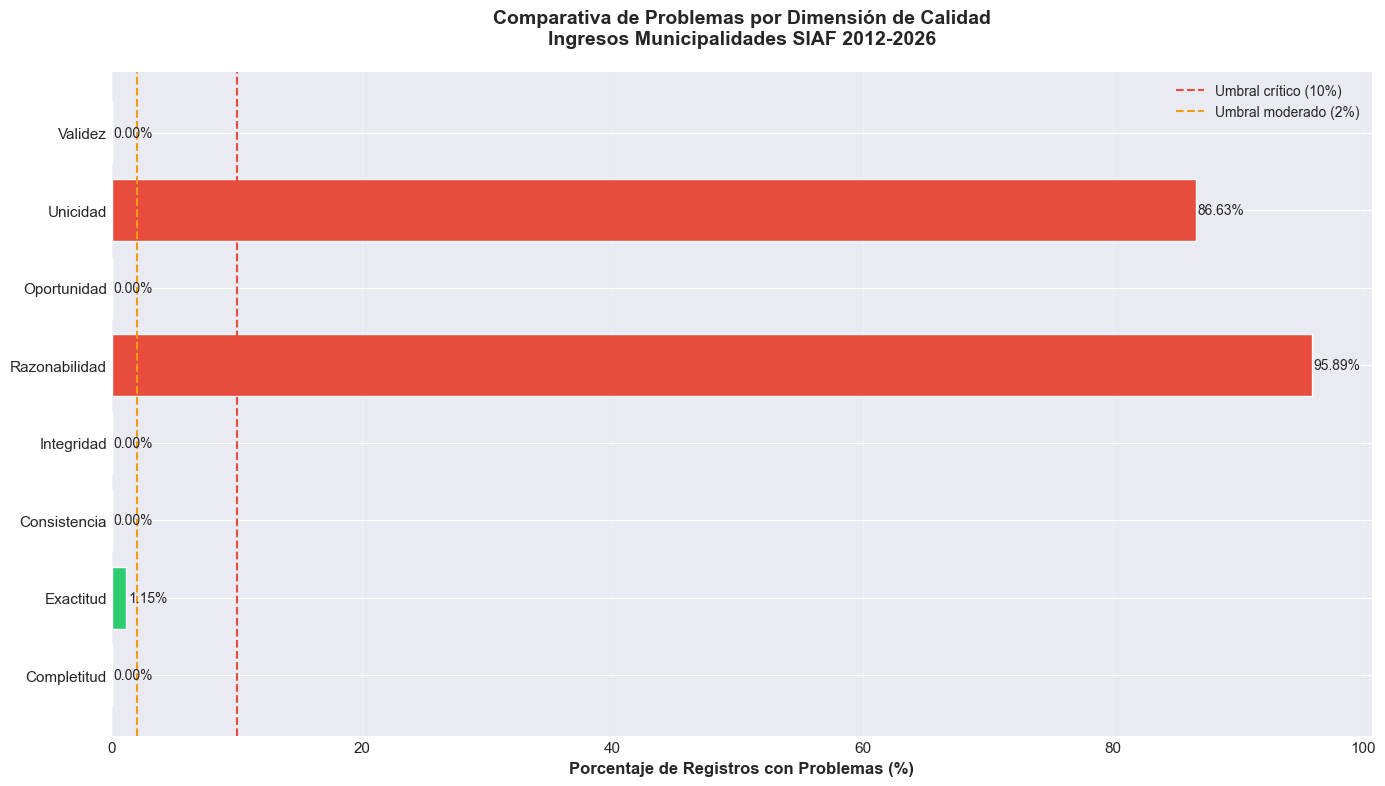

In [15]:
# Gráfico 1: Barras horizontales - Porcentaje de problemas por dimensión
# Ingresos Municipalidades SIAF 2012-2026

fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    '#e74c3c' if p > 10 else '#f39c12' if p > 2 else '#2ecc71'
    for p in df_metricas['porcentaje_problemas']
]

bars = ax.barh(
    df_metricas['dimension'],
    df_metricas['porcentaje_problemas'],
    color=colors,
    edgecolor='white'
)

ax.axvline(x=10, color='#e74c3c', linestyle='--',
           linewidth=1.5, label='Umbral crítico (10%)')
ax.axvline(x=2,  color='#f39c12', linestyle='--',
           linewidth=1.5, label='Umbral moderado (2%)')

ax.set_xlabel(
    'Porcentaje de Registros con Problemas (%)',
    fontsize=12, fontweight='bold'
)
ax.set_title(
    'Comparativa de Problemas por Dimensión de Calidad\n'
    'Ingresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold', pad=20
)
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=10)

for i, (dim, val) in enumerate(zip(
    df_metricas['dimension'],
    df_metricas['porcentaje_problemas']
)):
    ax.text(val + 0.15, i, f'{val:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

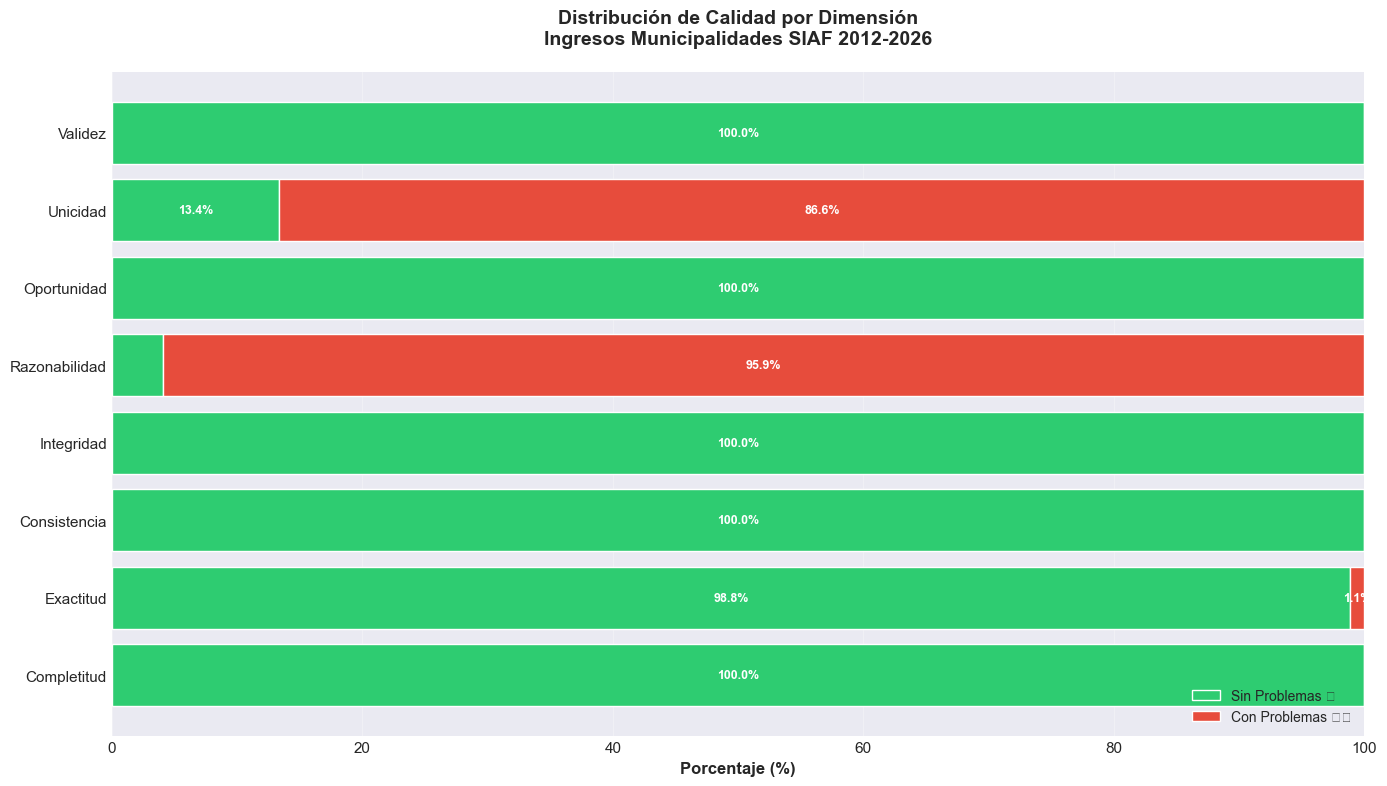

In [16]:
# Gráfico 2: Barras apiladas - OK vs Problemas por dimensión
# Ingresos Municipalidades SIAF 2012-2026

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(df_metricas))

ax.barh(
    x,
    df_metricas['porcentaje_ok'],
    label='Sin Problemas ✅',
    color='#2ecc71',
    edgecolor='white'
)
ax.barh(
    x,
    df_metricas['porcentaje_problemas'],
    left=df_metricas['porcentaje_ok'],
    label='Con Problemas ⚠️',
    color='#e74c3c',
    edgecolor='white'
)

ax.set_yticks(x)
ax.set_yticklabels(df_metricas['dimension'], fontsize=11)
ax.set_xlabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_title(
    'Distribución de Calidad por Dimensión\n'
    'Ingresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)

# Etiquetas de porcentaje en cada segmento
for i, (ok, prob) in enumerate(zip(
    df_metricas['porcentaje_ok'],
    df_metricas['porcentaje_problemas']
)):
    if ok > 5:
        ax.text(ok / 2, i, f'{ok:.1f}%',
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')
    if prob > 1:
        ax.text(ok + prob / 2, i, f'{prob:.1f}%',
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

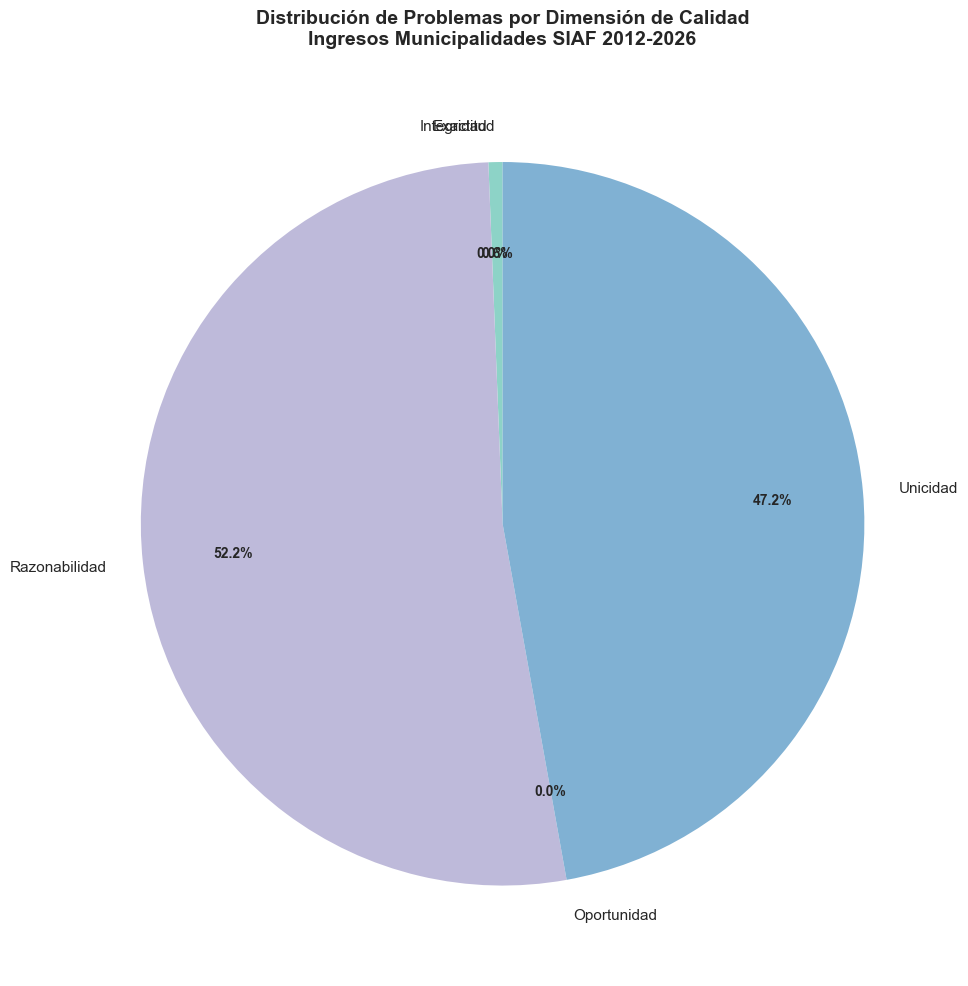

In [17]:
# Gráfico 3: Pastel - Distribución de problemas por dimensión
# Ingresos Municipalidades SIAF 2012-2026

# Solo graficar dimensiones que tienen problemas
df_con_problemas = df_metricas[df_metricas['problemas'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 10))
colors_pie = sns.color_palette('Set3', len(df_con_problemas))

if len(df_con_problemas) == 0:
    ax.text(0.5, 0.5, '✅ Sin problemas detectados\nen ninguna dimensión',
            ha='center', va='center', fontsize=14,
            transform=ax.transAxes)
else:
    wedges, texts, autotexts = ax.pie(
        df_con_problemas['problemas'],
        labels=df_con_problemas['dimension'],
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        pctdistance=0.75
    )
    for text in texts:
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

ax.set_title(
    'Distribución de Problemas por Dimensión de Calidad\n'
    'Ingresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.show()

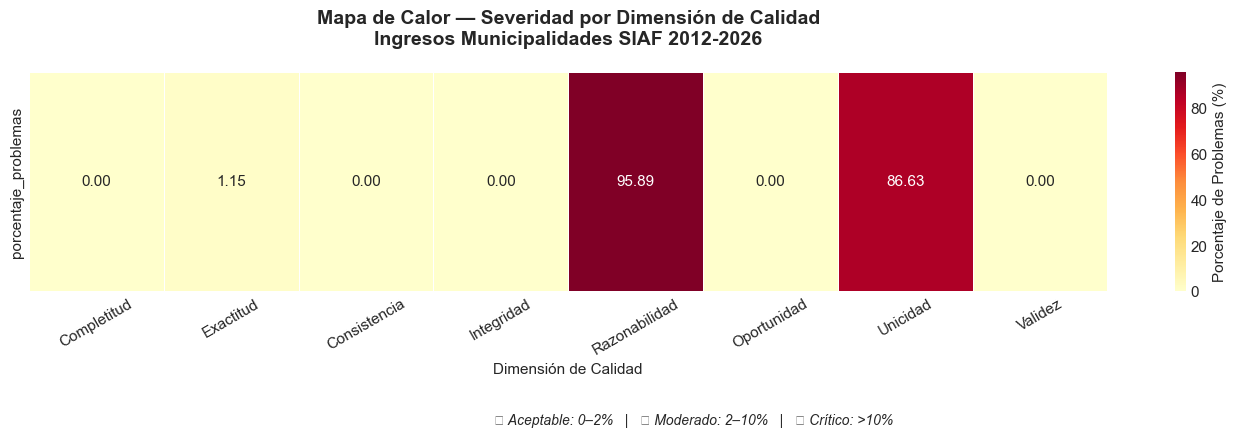

In [18]:
# Gráfico 4: Heatmap de severidad por dimensión
# Ingresos Municipalidades SIAF 2012-2026

severidad_data = df_metricas.copy()
severidad_data['Severidad'] = pd.cut(
    severidad_data['porcentaje_problemas'],
    bins=[0, 2, 10, 100],
    labels=['Aceptable', 'Moderado', 'Crítico']
)

fig, ax = plt.subplots(figsize=(14, 4))

severity_matrix = (
    severidad_data[['dimension', 'porcentaje_problemas']]
    .set_index('dimension')
    .T
)

sns.heatmap(
    severity_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Porcentaje de Problemas (%)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title(
    'Mapa de Calor — Severidad por Dimensión de Calidad\n'
    'Ingresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_ylabel('')
ax.set_xlabel('Dimensión de Calidad', fontsize=11)
ax.tick_params(axis='x', rotation=30)

# Leyenda de umbrales debajo del gráfico
fig.text(
    0.5, -0.08,
    '🟢 Aceptable: 0–2%   |   🟡 Moderado: 2–10%   |   🔴 Crítico: >10%',
    ha='center', fontsize=10, style='italic'
)

plt.tight_layout()
plt.show()

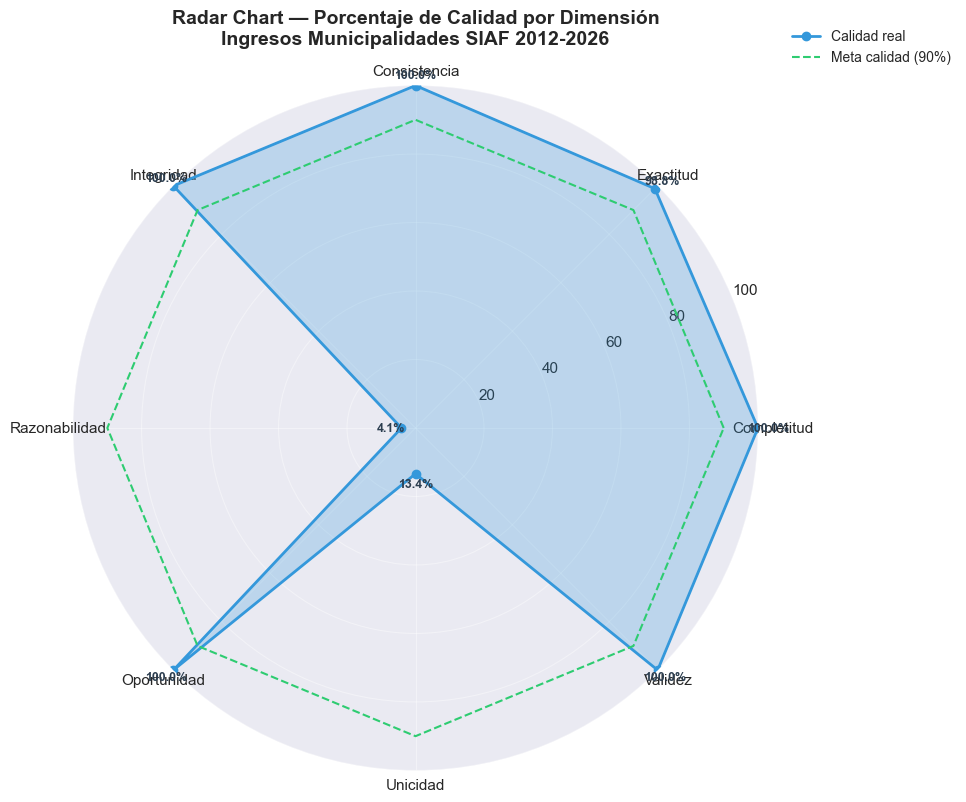

In [19]:
# Gráfico 5: Radar Chart - Porcentaje de calidad por dimensión
# Ingresos Municipalidades SIAF 2012-2026

from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Preparar datos
categorias = df_metricas['dimension'].tolist()
valores    = df_metricas['porcentaje_ok'].tolist()
valores   += valores[:1]  # Cerrar el polígono

# Calcular ángulos
N       = len(categorias)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1]

# Línea de referencia: meta de calidad (90%)
meta        = [90] * N
meta       += meta[:1]

# Dibujar área de calidad real
ax.plot(angulos, valores, 'o-', linewidth=2,
        color='#3498db', label='Calidad real')
ax.fill(angulos, valores, alpha=0.25, color='#3498db')

# Dibujar línea de meta
ax.plot(angulos, meta, '--', linewidth=1.5,
        color='#2ecc71', label='Meta calidad (90%)')

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_ylim(0, 100)

# Etiquetas de valor en cada vértice
for angulo, valor, cat in zip(angulos[:-1], valores[:-1], categorias):
    ax.text(
        angulo, valor + 3,
        f'{valor:.1f}%',
        ha='center', va='center',
        fontsize=9, color='#2c3e50', fontweight='bold'
    )

ax.set_title(
    'Radar Chart — Porcentaje de Calidad por Dimensión\n'
    'Ingresos Municipalidades SIAF 2012-2026',
    fontsize=14, fontweight='bold', pad=30
)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Conclusiones y Recomendaciones

In [20]:
# Identificar dimensiones más críticas - Ingresos Municipalidades SIAF

top_problemas  = df_metricas.nlargest(3, 'porcentaje_problemas')
mejor_calidad  = df_metricas.nsmallest(3, 'porcentaje_problemas')

print("=" * 65)
print("   CONCLUSIONES — ANÁLISIS DE CALIDAD DE DATOS")
print("   Ingresos Municipalidades SIAF 2012-2026")
print("=" * 65)

print("\n🔴 DIMENSIONES CON MAYOR PROBLEMÁTICA:")
for i, (idx, row) in enumerate(top_problemas.iterrows(), 1):
    print(f"   {i}. {row['dimension']:<20}: "
          f"{row['porcentaje_problemas']:.2f}% de registros afectados "
          f"({row['severidad']})")

print("\n🟢 DIMENSIONES CON MEJOR CALIDAD:")
for i, (idx, row) in enumerate(mejor_calidad.iterrows(), 1):
    print(f"   {i}. {row['dimension']:<20}: "
          f"{row['porcentaje_ok']:.2f}% de registros correctos")

print("\n📌 RECOMENDACIONES PARA LA CAPA SILVER:")
print("   1. Priorizar la corrección de las dimensiones críticas antes")
print("      de construir el modelo estrella en Gold")
print("   2. Filtrar solo NIVEL_GOBIERNO = 'M' como primer paso")
print("      del pipeline Silver para eliminar registros no municipales")
print("   3. Estandarizar el UBIGEO (6 dígitos) para garantizar el JOIN")
print("      entre SIAF, SISMEPRE y RENAMU")
print("   4. Establecer validaciones automáticas de montos negativos")
print("      y tasas de ejecución fuera de rango en el pipeline")
print("   5. Documentar cada decisión de limpieza con el número de")
print("      registros afectados antes y después de la corrección")
print("=" * 65)

   CONCLUSIONES — ANÁLISIS DE CALIDAD DE DATOS
   Ingresos Municipalidades SIAF 2012-2026

🔴 DIMENSIONES CON MAYOR PROBLEMÁTICA:
   1. Razonabilidad       : 95.89% de registros afectados (🔴 CRÍTICO)
   2. Unicidad            : 86.63% de registros afectados (🔴 CRÍTICO)
   3. Exactitud           : 1.15% de registros afectados (🟢 ACEPTABLE)

🟢 DIMENSIONES CON MEJOR CALIDAD:
   1. Completitud         : 100.00% de registros correctos
   2. Consistencia        : 100.00% de registros correctos
   3. Integridad          : 100.00% de registros correctos

📌 RECOMENDACIONES PARA LA CAPA SILVER:
   1. Priorizar la corrección de las dimensiones críticas antes
      de construir el modelo estrella en Gold
   2. Filtrar solo NIVEL_GOBIERNO = 'M' como primer paso
      del pipeline Silver para eliminar registros no municipales
   3. Estandarizar el UBIGEO (6 dígitos) para garantizar el JOIN
      entre SIAF, SISMEPRE y RENAMU
   4. Establecer validaciones automáticas de montos negativos
      y tasas 